This file can be used to quickly determine which features show a significant difference for each sensor

In [2]:
import pandas as pd
import os

def analyze_significant_qrs_area(csv_filepath, target_segment='T', target_feature='Area'):
    """
    Analyzes a CSV file to find sensors where a given feature is statistically significant
    in a specified segment. Outputs results and returns a filtered DataFrame.

    Args:
        csv_filepath (str): Path to the CSV file.
        target_segment (str): Segment name to filter by (e.g., 'T').
        target_feature (str): Feature name to filter by (e.g., 'Area').

    Returns:
        pd.DataFrame: Filtered DataFrame of significant sensor rows.
    """
    # 1. Validate that the input file exists
    if not os.path.exists(csv_filepath):
        print(f"❌ File not found: '{csv_filepath}'")
        return pd.DataFrame()

    # 2. Load the data
    try:
        df = pd.read_csv(csv_filepath)
        print(f"✅ Loaded data from '{csv_filepath}'")
    except Exception as e:
        print(f"❌ Error reading the CSV file: {e}")
        return pd.DataFrame()

    # 3. Check required columns
    significance_column = 'significant_ttest (mean_p<0.05)'
    required_columns = ['source', 'segment', 'feature', significance_column]
    for col in required_columns:
        if col not in df.columns:
            print(f"❌ Missing required column: '{col}'")
            return pd.DataFrame()

    # 4. Filter significant rows
    significant_rows = df[
        (df['segment'] == target_segment) &
        (df['feature'] == target_feature) &
        (df[significance_column] == True)
    ]

    # 5. Show results
    num_significant = len(significant_rows)
    print("\n" + "="*50)
    print(f"📊 Feature: '{target_feature}' | Segment: '{target_segment}'")
    print(f"✅ Statistically significant for {num_significant} sensor(s)")
    if num_significant > 0:
        display_cols = ['source']
        if 'p_value_mean' in significant_rows.columns:
            display_cols.append('p_value_mean')
        if 'p_value_ui_lower' in significant_rows.columns:
            display_cols.append('p_value_ui_lower')
        if 'p_value_ui_upper' in significant_rows.columns:
            display_cols.append('p_value_ui_upper')
            
        display(significant_rows[display_cols].reset_index(drop=True))
    else:
        print("No significant sensors found based on the criteria.")
    print("="*50)

    return significant_rows.reset_index(drop=True)


In [7]:
csv_path = 'Results/Overall_Generated_Tables/all_sensors_features_summary_mc.csv'

# Try changing these to other values 
segment = 'T' # 'T',  'QRS', "ST"
feature = 'Area_Hull' # Area_Net, 'Area_Hull', 'Solidity', 'Distance', 'Compact', 'Angle'

significant_sensors_df = analyze_significant_qrs_area(csv_path, target_segment=segment, target_feature=feature)


✅ Loaded data from 'Results/Overall_Generated_Tables/all_sensors_features_summary_mc.csv'

📊 Feature: 'Area_Hull' | Segment: 'T'
✅ Statistically significant for 14 sensor(s)


,source,p_value_mean,p_value_ui_lower,p_value_ui_upper
0,F0_yz,0.003643,0.000990,0.009038
1,OR_xy,0.026866,0.012423,0.048054
2,EZ_yz,0.011013,0.001893,0.037769
3,OX_xy,0.017336,0.006573,0.037269
4,OW_yz,0.002065,0.000806,0.004510
5,OO_yz,0.010785,0.005366,0.019025
6,C1_xy,0.001463,0.000152,0.006160
7,OY_xy,0.006524,0.001735,0.016900
8,F2_xy,0.019440,0.009654,0.036377
9,EY_xy,0.046222,0.016899,0.092075


In [4]:
csv_path = 'Results/Overall_Generated_Tables/aggregated_projection_summary_mc.csv'

# Try changing these to other values 
segment = 'QRS' # 'Compact',  'QRS', "ST"
feature = 'Distance' # Area_Net, 'Area_Hull', 'Solidity', 'Distance', 'Compact', 'Angle'

significant_sensors_df = analyze_significant_qrs_area(csv_path, target_segment=segment, target_feature=feature)


✅ Loaded data from 'Results/Overall_Generated_Tables/aggregated_projection_summary_mc.csv'

📊 Feature: 'Distance' | Segment: 'QRS'
✅ Statistically significant for 6 sensor(s)


,source,p_value_mean,p_value_ui_lower,p_value_ui_upper
0,aggregated_TopLeft_yz,0.005215,0.001076,0.014593
1,aggregated_TopRight_xy,0.010940,0.001274,0.039713
2,aggregated_TopRight_yz,0.002896,0.000479,0.009218
3,aggregated_BottomLeft_xy,0.018275,0.008900,0.035401
4,aggregated_BottomRight_xy,0.007402,0.002414,0.018466
5,aggregated_BottomRight_yz,0.036638,0.008618,0.098511


In [8]:
import pandas as pd
import os

def analyze_fdr_corrected_significance(
    csv_filepath,
    target_segment='T',
    target_feature='Area_Hull',
    q_threshold=0.05,
    robust_only=False,
):
    """
    Analyzes FDR-corrected significance for one segment/feature combination.

    Set robust_only=True to keep only rows that are both FDR-significant and
    robust across the Monte Carlo uncertainty interval.
    """
    if not os.path.exists(csv_filepath):
        print(f"❌ File not found: '{csv_filepath}'")
        return pd.DataFrame()

    try:
        df = pd.read_csv(csv_filepath)
        print(f"✅ Loaded data from '{csv_filepath}'")
    except Exception as e:
        print(f"❌ Error reading the CSV file: {e}")
        return pd.DataFrame()

    fdr_column = 'significant_fdr_q<0.05'
    robust_column = 'robust_after_fdr_and_mc_ui'
    q_column = 'q_value_fdr'
    p_column = 'p_value_mean'
    uncorrected_column = 'significant_ttest (mean_p<0.05)'

    required_columns = ['source', 'segment', 'feature', fdr_column, robust_column, q_column]
    for col in required_columns:
        if col not in df.columns:
            print(f"❌ Missing required column: '{col}'")
            return pd.DataFrame()

    feature_rows = df[
        (df['segment'] == target_segment) &
        (df['feature'] == target_feature)
    ].copy()

    if feature_rows.empty:
        print()
        print("="*60)
        print(f"📊 Feature: '{target_feature}' | Segment: '{target_segment}'")
        print("No rows found for this segment/feature combination.")
        print("="*60)
        return feature_rows

    fdr_rows = feature_rows[feature_rows[q_column] < q_threshold].copy()
    robust_rows = feature_rows[feature_rows[robust_column] == True].copy()
    result_rows = robust_rows if robust_only else fdr_rows

    if q_column in result_rows.columns:
        result_rows = result_rows.sort_values(q_column)

    print()
    print("="*60)
    print(f"📊 FDR-corrected feature: '{target_feature}' | Segment: '{target_segment}'")
    print(f"Rows tested: {len(feature_rows)}")
    if uncorrected_column in feature_rows.columns:
        print(f"Uncorrected p<0.05: {int(feature_rows[uncorrected_column].sum())}")
    print(f"FDR q<{q_threshold}: {len(fdr_rows)}")
    print(f"Robust after FDR + MC UI: {len(robust_rows)}")
    print(f"Displayed rows: {len(result_rows)} ({'robust only' if robust_only else 'all FDR-significant'})")

    if result_rows.empty:
        print("No FDR-corrected significant rows found based on the criteria.")
    else:
        display_cols = ['source']
        for col in [
            'sensor_or_region', 'projection', p_column, 'p_value_ui_lower', 'p_value_ui_upper',
            q_column, fdr_column, robust_column, 't_stat_mean', 'auc_mean',
            'sensitivity_mean', 'specificity_mean', 'roc_positive_class_for_metrics'
        ]:
            if col in result_rows.columns and col not in display_cols:
                display_cols.append(col)

        display(result_rows[display_cols].reset_index(drop=True))

    print("="*60)
    return result_rows.reset_index(drop=True)


# Try changing these values
segment = 'QRS'  # 'T', 'QRS', 'ST'
feature = 'Distance'  # Area_Net, Area_Hull, Solidity, Distance, Compact, Angle
robust_only = False

fdr_csv_paths = [
    'Results/Overall_Generated_Tables/all_sensors_features_summary_mc_fdr.csv',
    'Results/Overall_Generated_Tables/aggregated_projection_summary_mc_fdr.csv',
]

fdr_significant_results = {
    csv_path: analyze_fdr_corrected_significance(
        csv_path,
        target_segment=segment,
        target_feature=feature,
        robust_only=robust_only,
    )
    for csv_path in fdr_csv_paths
}


✅ Loaded data from 'Results/Overall_Generated_Tables/all_sensors_features_summary_mc_fdr.csv'

📊 FDR-corrected feature: 'Distance' | Segment: 'QRS'
Rows tested: 16
Uncorrected p<0.05: 12
FDR q<0.05: 9
Robust after FDR + MC UI: 8
Displayed rows: 9 (all FDR-significant)


,source,sensor_or_region,projection,p_value_mean,p_value_ui_lower,p_value_ui_upper,q_value_fdr,significant_fdr_q<0.05,robust_after_fdr_and_mc_ui,t_stat_mean,auc_mean,sensitivity_mean,specificity_mean,roc_positive_class_for_metrics
0,NL_yz,NL,yz,0.001164,0.000111,0.004413,0.009314,True,True,4.084297,0.914957,0.872317,0.881511,Healthy
1,F2_xy,F2,xy,0.001629,0.000648,0.003781,0.013034,True,True,4.256236,0.952749,0.840982,0.991244,Healthy
2,OO_yz,OO,yz,0.003356,0.000400,0.012337,0.013425,True,True,3.594823,0.864856,0.782350,0.887244,Healthy
3,OW_yz,OW,yz,0.006259,0.001837,0.014416,0.016690,True,True,3.282860,0.876235,0.769950,0.884222,Healthy
4,OR_xy,OR,xy,0.010594,0.004261,0.023481,0.021877,True,True,3.084968,0.785489,0.653164,0.948244,Healthy
5,C1_xy,C1,xy,0.010939,0.002394,0.031256,0.021877,True,True,2.990690,0.840688,0.810233,0.796971,Healthy
6,OY_xy,OY,xy,0.009287,0.001524,0.028377,0.021877,True,True,3.041741,0.823570,0.797433,0.811711,Healthy
7,F0_yz,F0,yz,0.018729,0.004695,0.047367,0.037458,True,True,2.849455,0.871231,0.882133,0.812525,Healthy
8,YQ_xy,YQ,xy,0.024654,0.005701,0.066017,0.039447,True,False,2.551416,0.812210,0.801000,0.840125,Healthy


✅ Loaded data from 'Results/Overall_Generated_Tables/aggregated_projection_summary_mc_fdr.csv'

📊 FDR-corrected feature: 'Distance' | Segment: 'QRS'
Rows tested: 8
Uncorrected p<0.05: 6
FDR q<0.05: 6
Robust after FDR + MC UI: 5
Displayed rows: 6 (all FDR-significant)


,source,sensor_or_region,projection,p_value_mean,p_value_ui_lower,p_value_ui_upper,q_value_fdr,significant_fdr_q<0.05,robust_after_fdr_and_mc_ui,t_stat_mean,auc_mean,sensitivity_mean,specificity_mean,roc_positive_class_for_metrics
0,aggregated_TopLeft_yz,aggregated_TopLeft,yz,0.005275,0.001063,0.014872,0.010549,True,True,3.327398,0.848667,0.789600,0.884422,Healthy
1,aggregated_TopRight_yz,aggregated_TopRight,yz,0.002844,0.000473,0.008316,0.010549,True,True,3.667706,0.892889,0.769567,0.925044,Healthy
2,aggregated_TopRight_xy,aggregated_TopRight,xy,0.011200,0.001403,0.041017,0.022401,True,True,2.988530,0.815165,0.689117,0.886089,Healthy
3,aggregated_BottomRight_xy,aggregated_BottomRight,xy,0.007414,0.002370,0.018439,0.022401,True,True,3.214710,0.832761,0.805233,0.835111,Healthy
4,aggregated_BottomLeft_xy,aggregated_BottomLeft,xy,0.018215,0.008972,0.035439,0.024286,True,True,2.742213,0.782656,0.753717,0.849378,Healthy
5,aggregated_BottomRight_yz,aggregated_BottomRight,yz,0.035849,0.008410,0.097025,0.047798,True,False,2.378855,0.743344,0.596367,0.877956,Healthy


## Determine Age Corelation

✅ Loaded demographics for 21 subjects from JSON.

📊 ANALYSIS FOR: result.csv
   Metric: t_Area_Hull
   Healthy Controls Found: 12
Spearman Correlation (Rank): r = -0.270, p = 0.3957
Pearson Correlation (Lin.) : r = -0.032, p = 0.9212
------------------------------------------------------------
✅ RESULT: No significant correlation with age (p > 0.05).
   -> You can argue age is NOT the confounder.


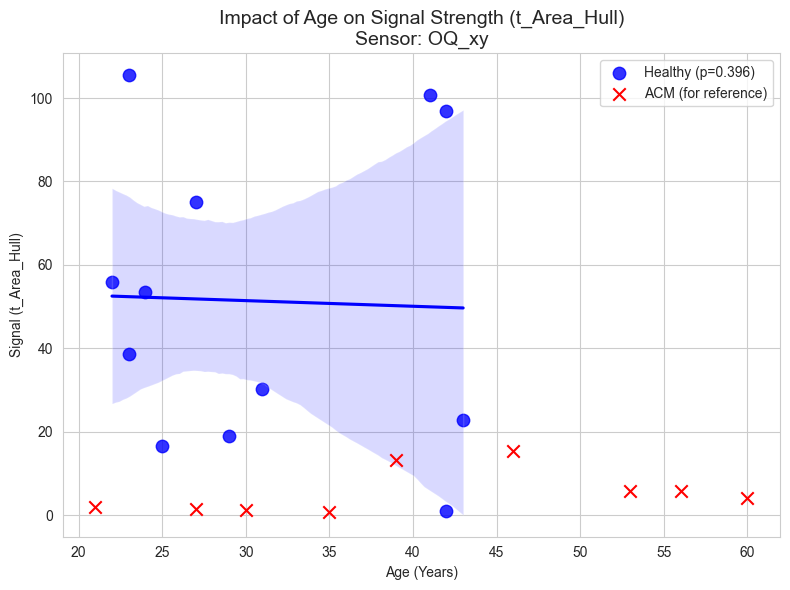

In [1]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import os

def analyze_age_correlation_from_json(
    json_filepath, 
    results_csv_filepath, 
    segment='t', 
    feature='Area_Hull'
):
    """
    Parses patient metadata from JSON, merges with sensor results, 
    and checks Age correlation in Healthy Controls.
    """
    # ==========================================
    # 1. PARSE THE JSON (Demographics)
    # ==========================================
    if not os.path.exists(json_filepath):
        print(f"❌ JSON file not found: {json_filepath}")
        return

    with open(json_filepath, 'r') as f:
        data = json.load(f)

    # Convert JSON dictionary to a list of dictionaries for Pandas
    patients_list = []
    for pid, details in data.items():
        # 1. Get Age
        age = details.get('age')
        
        # 2. Determine Group (ACM vs Healthy)
        # We look inside the first run found in the "runs" dictionary
        # (Assuming patient status doesn't change between runs)
        runs = details.get('runs', {})
        if not runs:
            continue # Skip if no runs
            
        first_run_key = list(runs.keys())[0]
        is_acm = runs[first_run_key].get('ACM', False)
        group = 'ACM' if is_acm else 'Healthy'
        
        patients_list.append({
            'patient': pid,
            'Age': age,
            'Group': group
        })

    df_demo = pd.DataFrame(patients_list)
    print(f"✅ Loaded demographics for {len(df_demo)} subjects from JSON.")

    # ==========================================
    # 2. LOAD SENSOR RESULTS
    # ==========================================
    if not os.path.exists(results_csv_filepath):
        print(f"❌ Results file not found: {results_csv_filepath}")
        return

    df_results = pd.read_csv(results_csv_filepath)
    
    # Construct the column name (e.g., 't_Area_Hull')
    target_col = f"{segment}_{feature}"
    
    if target_col not in df_results.columns:
        print(f"❌ Feature '{target_col}' not found in CSV.")
        return

    # ==========================================
    # 3. MERGE DATA
    # ==========================================
    # We strip whitespace just in case ' P001 ' vs 'P001'
    df_results['patient'] = df_results['patient'].astype(str).str.strip()
    df_demo['patient'] = df_demo['patient'].astype(str).str.strip()

    merged_df = pd.merge(df_results, df_demo, on='patient', how='inner')
    
    # ==========================================
    # 4. FILTER FOR HEALTHY CONTROLS
    # ==========================================
    controls = merged_df[merged_df['Group'] == 'Healthy']
    
    print("\n" + "="*60)
    print(f"📊 ANALYSIS FOR: {os.path.basename(results_csv_filepath)}")
    print(f"   Metric: {target_col}")
    print(f"   Healthy Controls Found: {len(controls)}")
    print("="*60)

    if len(controls) < 5:
        print("⚠️ Warning: Sample size too small for reliable correlation.")

    # ==========================================
    # 5. STATISTICS
    # ==========================================
    # Spearman (Rank) is safer for small sample sizes
    spearman_r, spearman_p = stats.spearmanr(controls['Age'], controls[target_col])
    
    # Pearson (Linear)
    pearson_r, pearson_p = stats.pearsonr(controls['Age'], controls[target_col])

    print(f"Spearman Correlation (Rank): r = {spearman_r:.3f}, p = {spearman_p:.4f}")
    print(f"Pearson Correlation (Lin.) : r = {pearson_r:.3f}, p = {pearson_p:.4f}")
    print("-" * 60)

    if spearman_p > 0.05:
        print("✅ RESULT: No significant correlation with age (p > 0.05).")
        print("   -> You can argue age is NOT the confounder.")
    else:
        print("❌ RESULT: Significant correlation found.")
        print("   -> You must discuss this as a limitation.")

    # ==========================================
    # 6. PLOT
    # ==========================================
    sns.set_style("whitegrid")
    plt.figure(figsize=(8, 6))
    
    # Plot Healthy in Blue
    sns.regplot(data=controls, x='Age', y=target_col, 
                color='blue', label=f'Healthy (p={spearman_p:.3f})',
                scatter_kws={'s': 80})
    
    # Optional: Plot ACM in Red just for visual comparison (don't include in correlation)
    acm_patients = merged_df[merged_df['Group'] == 'ACM']
    plt.scatter(acm_patients['Age'], acm_patients[target_col], 
                color='red', marker='x', s=80, label='ACM (for reference)')

    plt.title(f"Impact of Age on Signal Strength ({target_col})\nSensor: {os.path.basename(os.path.dirname(results_csv_filepath))}", fontsize=14)
    plt.xlabel("Age (Years)")
    plt.ylabel(f"Signal ({target_col})")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ==========================================
# RUN CONFIGURATION
# ==========================================

# 1. Path to your JSON file
json_path = 'Data/setup.json'


"""
F0_yz	0.003629	0.001023	0.008872
1	OR_xy	0.027051	0.012338	0.047937
2	EZ_yz	0.011006	0.001926	0.039347
3	OX_xy	0.017102	0.006345	0.036078
4	OW_yz	0.002089	0.000800	0.004499
5	OO_yz	0.010776	0.005292	0.019030
6	C1_xy	0.001451	0.000146	0.005996
7	OY_xy	0.006663	0.001763	0.017385
8	F2_xy	0.019553	0.009898	0.035458
9	EY_xy	0.046325	0.017057	0.091746
10	YP_yz	0.014227	0.002553	0.033937
11	NL_yz	0.026943	0.012477	0.049101
12	OT_yz	0.010632	0.003745	0.023593
13	OQ_xy	
"""

# 2. Path to the sensor result file 
# TIP: Use the sensor that had the best P-value in your paper (e.g. C1 or OQ)
csv_path = 'Results/OQ_xy/result.csv'

# 3. Parameters
analyze_age_correlation_from_json(
    json_path, 
    csv_path, 
    segment='t',        # 't', 'qrs', or 'st'
    feature='Area_Hull' # 'Area_Hull', 'Distance', 'Solidity'
)

✅ Loaded Demographics: 21 subjects
📍 Analyzing TopRight (yz)
   Sensors: ['OO', 'OQ', 'OY', 'OW']
   ⚠️ Missing file: OQ_yz
   ⚠️ Missing file: OY_yz
✅ Aggregated data for 21 patients.
✅ Filtered for Healthy Controls: N = 12

📊 t_Area_Hull vs AGE
--------------------------------------------------
Spearman Rho : -0.400
P-Value      : 0.1976
✅ No significant correlation (Age is NOT a confounder).


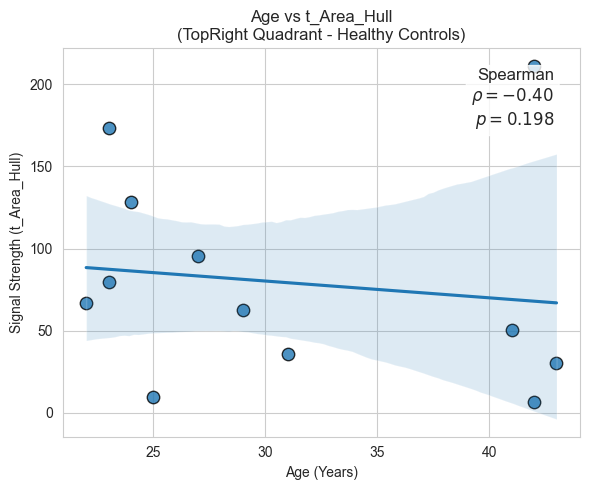


📊 qrs_Distance vs AGE
--------------------------------------------------
Spearman Rho : -0.337
P-Value      : 0.2843
✅ No significant correlation (Age is NOT a confounder).


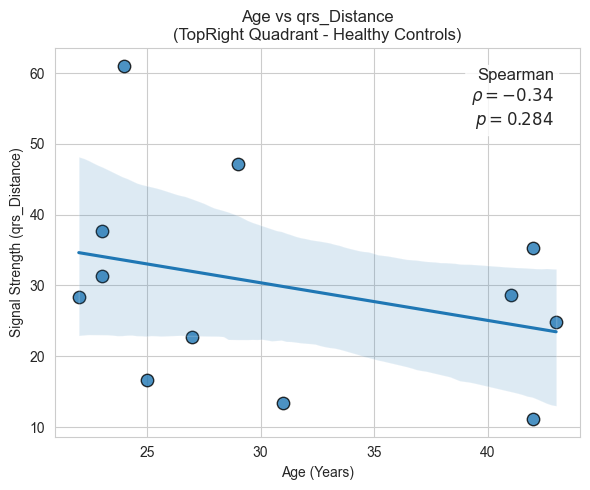


📊 t_Area_Net vs AGE
--------------------------------------------------
Spearman Rho : -0.354
P-Value      : 0.2584
✅ No significant correlation (Age is NOT a confounder).


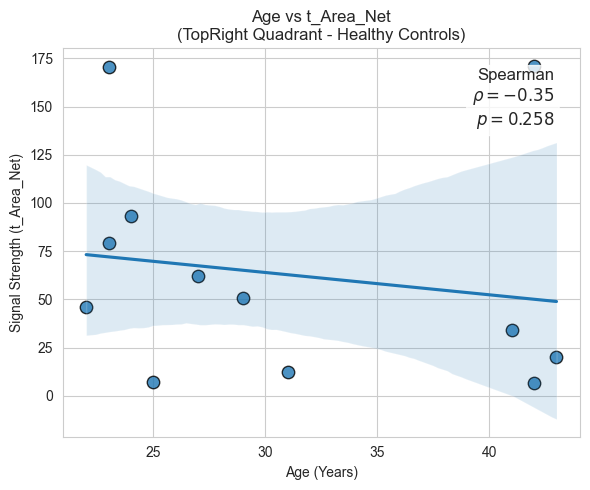

In [10]:
import pandas as pd
import numpy as np
import json
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

# ======================================================
# CONFIGURATION
# ======================================================
# 1. Define the Quadrant you want to analyze (The "Best" one from your paper)
#    Usually "BottomRight" or "TopRight"
TARGET_QUADRANT = "TopRight"  # Options: TopLeft, TopRight, BottomLeft, BottomRight
TARGET_PROJECTION = "yz"         # Options: xy, yz

# 2. Define the Feature to correlate with Age
#    Use the short name from your script (e.g., t_Area_Hull, qrs_Distance)
TARGET_FEATURES = ["t_Area_Hull", "qrs_Distance", "t_Area_Net"] 

# 3. Paths
JSON_PATH = "Data/setup.json"
RESULTS_BASE_DIR = "Results"

# ======================================================
# 1. LOAD DEMOGRAPHICS (Age & Group)
# ======================================================
with open(JSON_PATH, 'r') as f:
    patient_meta = json.load(f)

demo_records = []
for pid, p_data in patient_meta.items():
    # Extract Age
    age = p_data.get("age")
    
    # Extract ACM Status from the first run found
    runs = p_data.get("runs", {})
    if not runs: continue
    first_run_id = list(runs.keys())[0]
    is_acm = runs[first_run_id].get("ACM", False)
    
    demo_records.append({
        "patient": pid,
        "age": int(age) if age else None,
        "ACM": is_acm
    })

df_demo = pd.DataFrame(demo_records)
# Clean IDs just in case
df_demo['patient'] = df_demo['patient'].astype(str).str.strip()

print(f"✅ Loaded Demographics: {len(df_demo)} subjects")

# ======================================================
# 2. DEFINE QUADRANT SENSORS
# ======================================================
# This map matches the logic in your main script
sensor_grid = [
    ["F1", "OX", "OO", "OQ"], 
    ["YQ", "NL", "OY", "OW"], 
    ["OT", "F2", "F0", "C1"], 
    ["EY", "YP", "OR", "EZ"]
]

# Indices for slices [row_start:row_end, col_start:col_end]
slices = {
    "TopLeft":     (slice(0, 2), slice(0, 2)), 
    "TopRight":    (slice(0, 2), slice(2, 4)),
    "BottomLeft":  (slice(2, 4), slice(0, 2)),
    "BottomRight": (slice(2, 4), slice(2, 4))
}

row_s, col_s = slices[TARGET_QUADRANT]
sensors_in_quadrant = [
    sensor_grid[r][c] 
    for r in range(row_s.start, row_s.stop) 
    for c in range(col_s.start, col_s.stop)
]

print(f"📍 Analyzing {TARGET_QUADRANT} ({TARGET_PROJECTION})")
print(f"   Sensors: {sensors_in_quadrant}")

# ======================================================
# 3. LOAD & AGGREGATE SENSOR DATA
# ======================================================
dfs_to_agg = []

for sid in sensors_in_quadrant:
    folder_name = f"{sid}_{TARGET_PROJECTION}"
    file_path = os.path.join(RESULTS_BASE_DIR, folder_name, "result.csv")
    
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            # Add identifiers for debugging
            df['sensor'] = sid
            dfs_to_agg.append(df)
        except Exception as e:
            print(f"   ⚠️ Error reading {sid}: {e}")
    else:
        print(f"   ⚠️ Missing file: {folder_name}")

if not dfs_to_agg:
    raise ValueError("No data found for this quadrant!")

# Concatenate all sensor files
df_concat = pd.concat(dfs_to_agg, ignore_index=True)
df_concat['patient'] = df_concat['patient'].astype(str).str.strip()

# GROUP BY PATIENT and calculate MEAN of the feature columns
# Note: We need to convert column names to lowercase to match your script's output convention
# or stick to the raw column names in result.csv (e.g. t_Area_Hull)
# Your script usually saves them as "t_area_hull" in the summary, 
# but "t_Area_Hull" in the raw result.csv. Let's check raw cols.

# Calculate Mean for each patient across the 4 sensors
# We group by patient (and run if needed)
df_agg = df_concat.groupby('patient')[TARGET_FEATURES].mean().reset_index()

print(f"✅ Aggregated data for {len(df_agg)} patients.")

# ======================================================
# 4. MERGE & FILTER (HEALTHY ONLY)
# ======================================================
df_final = pd.merge(df_agg, df_demo, on='patient', how='inner')

# Filter for HEALTHY
df_healthy = df_final[df_final['ACM'] == False].copy()

print(f"✅ Filtered for Healthy Controls: N = {len(df_healthy)}")

# ======================================================
# 5. RUN SPEARMAN CORRELATION & PLOT
# ======================================================
sns.set_style("whitegrid")

for feat in TARGET_FEATURES:
    # Check if data exists
    if feat not in df_healthy.columns:
        print(f"Feature {feat} not found.")
        continue
        
    data_for_corr = df_healthy[['age', feat]].dropna()
    
    # Run Spearman
    rho, p_val = spearmanr(data_for_corr['age'], data_for_corr[feat])
    
    # Console Output (Copy this to your paper!)
    print("\n" + "="*50)
    print(f"📊 {feat} vs AGE")
    print("-" * 50)
    print(f"Spearman Rho : {rho:.3f}")
    print(f"P-Value      : {p_val:.4f}")
    
    if p_val > 0.05:
        print("✅ No significant correlation (Age is NOT a confounder).")
    else:
        print("⚠️ Significant correlation found.")
    print("="*50)

    # Plot
    plt.figure(figsize=(6, 5))
    sns.regplot(data=data_for_corr, x='age', y=feat, 
                color='#1f77b4', scatter_kws={'s':80, 'edgecolor':'k'})
    
    # Add stats to plot
    plt.title(f"Age vs {feat}\n({TARGET_QUADRANT} Quadrant - Healthy Controls)", fontsize=12)
    plt.xlabel("Age (Years)")
    plt.ylabel(f"Signal Strength ({feat})")
    
    # Add text box
    text_str = f"Spearman\n$\\rho = {rho:.2f}$\n$p = {p_val:.3f}$"
    plt.gca().text(0.95, 0.95, text_str, transform=plt.gca().transAxes, 
                   fontsize=12, verticalalignment='top', horizontalalignment='right',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()